# Phase 1 — Analyse de séquences géniques (Biopython)

Objectif : compléter OncoPrint (qui traite les gènes comme des colonnes d'un tableau multi-omique) par une lecture biologique directe de leur séquence — composition, traduction, comparaison structurale.

**Choix des gènes : les 5 features les plus importantes en SHAP dans OncoPrint**, un par sous-type (source : `OncoPrint_Final.ipynb`, cellule 52) :

| Gène | Sous-type où il domine en SHAP | Rôle biologique |
| --- | --- | --- |
| **ESR1** (ER-alpha) | Luminal A (1er, SHAP 0.558) | Récepteur aux œstrogènes, cible de l'hormonothérapie |
| **ERBB2** (HER2) | HER2-enrichi (2e, SHAP 0.584) | Déjà central en Phase 2 (cible du trastuzumab) |
| **FOXA1** | Triple Négatif (4e, SHAP 0.198) | Facteur de transcription "pionnier", luminal et TNBC |
| **AR** (récepteur aux androgènes) | Triple Négatif (5e, SHAP 0.191) | Voie ciblée en essais cliniques dans les TNBC AR+ |
| **GATA3** | Luminal A (5e, SHAP 0.173) | Facteur de différenciation luminale |

Séquences récupérées en direct depuis **NCBI RefSeq** via Biopython (`Bio.Entrez`), fonctions dans `src/sequence_analysis.py`.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
from sequence_analysis import analyze_gene

GENES = ["ESR1", "ERBB2", "FOXA1", "AR", "GATA3"]
results = [analyze_gene(g) for g in GENES]
for r in results:
    print(r["gene"], "->", r.get("accession"), "-", r.get("description", r.get("error")))

ESR1 -> NM_001122740 - Homo sapiens estrogen receptor 1 (ESR1), transcript variant 2, mRNA
ERBB2 -> NM_001005862 - Homo sapiens erb-b2 receptor tyrosine kinase 2 (ERBB2), transcript variant 2, mRNA
FOXA1 -> NM_004496 - Homo sapiens forkhead box A1 (FOXA1), mRNA
AR -> NM_000044 - Homo sapiens androgen receptor (AR), transcript variant 1, mRNA
GATA3 -> NM_001002295 - Homo sapiens GATA binding protein 3 (GATA3), transcript variant 1, mRNA


## 1. Comparaison des 5 gènes

Composition GC de l'ARNm, longueur et propriétés physico-chimiques de la protéine traduite (même logique que les descripteurs RDKit en Phase 2, appliquée à des macromolécules biologiques plutôt qu'à des petites molécules).

In [2]:
df = pd.DataFrame(results).drop(columns=["protein_sequence"])
df

,gene,accession,description,mrna_length,mrna_gc_percent,cds_length_nt,protein_length_aa,protein_mw_kda,instability_index,aromaticity,isoelectric_point
0,ESR1,NM_001122740,"Homo sapiens estrogen receptor 1 (ESR1), trans...",6480,46.64,1788,595,66.22,45.88,0.072,8.30
1,ERBB2,NM_001005862,Homo sapiens erb-b2 receptor tyrosine kinase 2...,4858,58.23,3678,1225,134.85,56.63,0.069,5.61
2,FOXA1,NM_004496,"Homo sapiens forkhead box A1 (FOXA1), mRNA",3509,50.44,1419,472,49.15,55.56,0.076,8.93
3,AR,NM_000044,"Homo sapiens androgen receptor (AR), transcrip...",10667,48.06,2763,920,99.19,56.78,0.075,6.01
4,GATA3,NM_001002295,"Homo sapiens GATA binding protein 3 (GATA3), t...",3083,53.71,1335,444,48.04,64.56,0.065,9.47


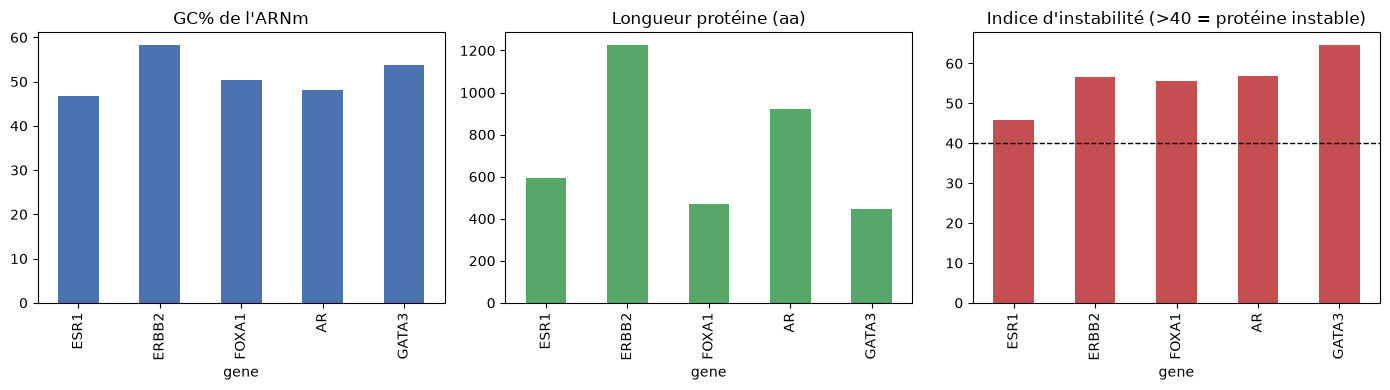

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df.plot.bar(x="gene", y="mrna_gc_percent", ax=axes[0], legend=False, color="#4C72B0")
axes[0].set_title("GC% de l'ARNm")
df.plot.bar(x="gene", y="protein_length_aa", ax=axes[1], legend=False, color="#55A868")
axes[1].set_title("Longueur protéine (aa)")
df.plot.bar(x="gene", y="instability_index", ax=axes[2], legend=False, color="#C44E52")
axes[2].axhline(40, color="black", linestyle="--", linewidth=1)
axes[2].set_title("Indice d'instabilité (>40 = protéine instable)")
plt.tight_layout()

## 2. Un variant clinique connu, retrouvé directement dans la séquence traduite

**ESR1 Y537S** est une des mutations de résistance à l'hormonothérapie les mieux documentées dans le cancer du sein métastatique : elle rend le récepteur aux œstrogènes actif *sans* œstrogène, dans le domaine de liaison au ligand (autour du résidu 537).

On vérifie que la protéine qu'on vient de traduire depuis le RefSeq NCBI porte bien une tyrosine (Y) à cette position — sans base de données de variants, juste en lisant la séquence traduite.

In [4]:
esr1_protein = next(r for r in results if r["gene"] == "ESR1")["protein_sequence"]
position = 537
residue = esr1_protein[position - 1]

print(f"Résidu en position {position} : {residue}")
print(f"Contexte (532-542) : {esr1_protein[position - 6:position + 5]}")
print("-> correspond au site de la mutation Y537S" if residue == "Y" else "-> ne correspond pas (variant de transcrit différent)")

Résidu en position 537 : Y
Contexte (532-542) : NVVPLYDLLLE
-> correspond au site de la mutation Y537S


## 3. Simulation de la mutation Y537S

On modifie la séquence traduite pour simuler la mutation, et on regarde son effet sur les propriétés physico-chimiques globales de la protéine (une vraie évaluation d'impact fonctionnel nécessiterait une structure 3D — hors scope ici, mais l'exercice illustre le principe).

In [5]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

mutated = esr1_protein[:position - 1] + "S" + esr1_protein[position:]

wt_analysis = ProteinAnalysis(esr1_protein)
mut_analysis = ProteinAnalysis(mutated)

comparison = pd.DataFrame({
    "ESR1 sauvage (Y537)": {
        "MW (kDa)": round(wt_analysis.molecular_weight() / 1000, 2),
        "Indice d'instabilité": round(wt_analysis.instability_index(), 2),
        "Point isoélectrique": round(wt_analysis.isoelectric_point(), 2),
    },
    "ESR1 muté (S537)": {
        "MW (kDa)": round(mut_analysis.molecular_weight() / 1000, 2),
        "Indice d'instabilité": round(mut_analysis.instability_index(), 2),
        "Point isoélectrique": round(mut_analysis.isoelectric_point(), 2),
    },
})
comparison

,ESR1 sauvage (Y537),ESR1 muté (S537)
MW (kDa),66.22,66.14
Indice d'instabilité,45.88,45.49
Point isoélectrique,8.30,8.30


In [6]:
df.to_csv("../data/processed/gene_sequence_analysis.csv", index=False)
print("Sauvegardé :", len(df), "gènes analysés")

Sauvegardé : 5 gènes analysés
